# Optimization Algorithms

<a target="_blank" href="https://colab.research.google.com/github/JunyoungB/statistical-computing-public/blob/main/ch8.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook covers unconstrained optimization problems and various optimization algorithms.
We primarily use simple functions to analyze algorithm characteristics and visualizations.

In [86]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

## Unconstrained Optimization

### Optimality Conditions for Unconstrained Optimization

For the function $f(x,y) = x^2 + y^3 - 3y^2 - 9y + 5$, we analyze critical points and their classification using symbolic computation.

In [87]:
x, y = sp.symbols('x y', real=True)
f_sym = x**2 + y**3 - 3*y**2 - 9*y + 5

grad_f_sym    = [sp.diff(f_sym, x), sp.diff(f_sym, y)]
critical_pts  = sp.solve(grad_f_sym, [x, y])

fxx = sp.diff(f_sym, x, 2)
fyy = sp.diff(f_sym, y, 2)
fxy = sp.diff(f_sym, x, y)
D   = fxx * fyy - fxy**2

print(f"f_xx = {fxx},  f_yy = {fyy},  f_xy = {fxy}")
print(f"D(x,y) = f_xx*f_yy - f_xy^2 = {sp.simplify(D)}")
print()

for pt in critical_pts:
    xv, yv = pt
    fval = float(f_sym.subs([(x, xv), (y, yv)]))
    Dval = float(D.subs([(x, xv), (y, yv)]))
    fxx_val = float(fxx.subs([(x, xv), (y, yv)]))
    if Dval > 0:
        label = "Local Min" if fxx_val > 0 else "Local Max"
    elif Dval < 0:
        label = "Saddle Point"
    else:
        label = "Inconclusive"
    print(f"({float(xv):.0f}, {float(yv):.0f}):  f = {fval:.1f},  D = {Dval:.1f},  f_xx = {fxx_val:.1f}  ->  {label}")

f_xx = 2,  f_yy = 6*(y - 1),  f_xy = 0
D(x,y) = f_xx*f_yy - f_xy^2 = 12*y - 12

(0, -1):  f = 10.0,  D = -24.0,  f_xx = 2.0  ->  Saddle Point
(0, 3):  f = -22.0,  D = 24.0,  f_xx = 2.0  ->  Local Min


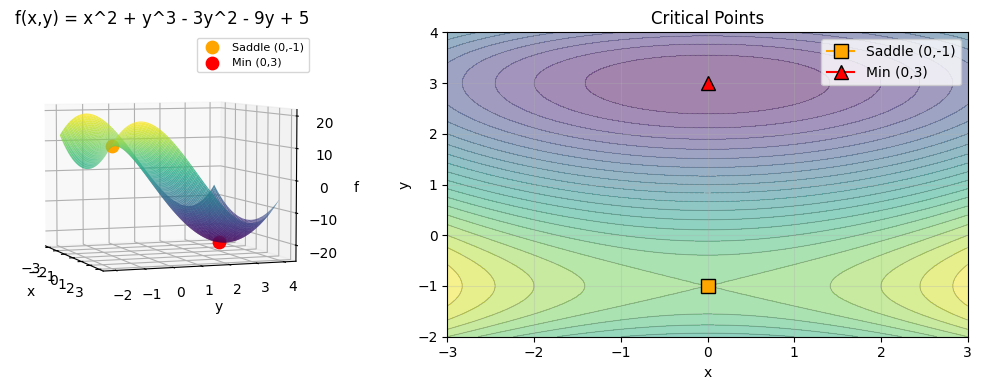

In [112]:
f_num = sp.lambdify([x, y], f_sym, 'numpy')
xr = np.linspace(-3, 3, 100)
yr = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(xr, yr)
Z = f_num(X, Y)

cp = [(0, -1, 'Saddle (0,-1)', 'orange', 's'),
      (0,  3, 'Min (0,3)',     'red',    '^')]

fig = plt.figure(figsize=(11, 4))

ax1 = fig.add_subplot(121, projection='3d')
ax1.view_init(elev=5, azim=-20)
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, linewidth=0)
for xv, yv, label, color, marker in cp:
    ax1.scatter([xv], [yv], [float(f_num(xv, yv))], color=color, s=80, label=label)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f')
ax1.set_title('f(x,y) = x^2 + y^3 - 3y^2 - 9y + 5')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(122)
ax2.contourf(X, Y, Z, levels=20, alpha=0.5, cmap='viridis')
ax2.contour(X, Y, Z, levels=20, colors='gray', alpha=0.5, linewidths=0.7)
for xv, yv, label, color, marker in cp:
    ax2.plot(xv, yv, marker=marker, color=color, markersize=10,
             markeredgecolor='k', label=label)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Critical Points')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Line Search Methods

In line search methods, at each iteration (update), a search direction $d_k$ is computed, and we decide how far to move along that direction. Each iteration is defined as:

$$x_{k+1} = x_k + \alpha_k d_k$$

where the positive scalar $\alpha_k$ is called the learning rate. The success of line search methods depends on how effectively we choose the search direction $d_k$ and learning rate $\alpha_k$.

In most line search methods, $d_k$ should be a descent direction - that is, $d_k^T \nabla f(x_k) < 0$ - and the search direction can be written in the form:

$$d_k = -B_k^{-1} \nabla f(x_k)$$

where $B_k$ is a symmetric and nonsingular matrix.

- **Gradient descent method**: $B_k = I$ (identity matrix)
- **Newton's method**: $B_k = \nabla^2 f(x_k)$ (Hessian)  
- **Quasi-Newton methods**: $B_k$ is an approximation to the Hessian, updated each iteration by low-rank formulas

### Search Direction Methods Comparison

The following example compares these three approaches ($B_k$ choices) on a single function.

In [114]:
def f(x):
    return x[0]**2 + x[1]**3 - 3*x[1]**2 - 9*x[1] + 5

def grad_f(x):
    return np.array([2*x[0], 3*x[1]**2 - 6*x[1] - 9])

def hess_f(x):
    h = 6*x[1] - 6
    return np.array([[2.0, 0.0], [0.0, max(h, 0.1)]])

def strong_wolfe(x, d, c1=1e-4, c2=0.9, max_iter=50):
    """Strong Wolfe line search: Armijo + curvature condition"""
    alpha = 1.0
    phi0  = f(x)
    dphi0 = np.dot(grad_f(x), d)
    if dphi0 >= 0:
        return 0.0
    for _ in range(max_iter):
        x_new = x + alpha * d
        phi   = f(x_new)
        if phi > phi0 + c1 * alpha * dphi0:
            alpha *= 0.5          # Armijo violated -> shrink
            continue
        dphi = np.dot(grad_f(x_new), d)
        if abs(dphi) <= c2 * abs(dphi0):
            return alpha          # both conditions satisfied
        if dphi > 0:
            alpha *= 0.5          # overshot minimum of phi -> shrink
        else:
            alpha = min(alpha * 1.5, 2.0)   # still descending -> grow
    return alpha

F_STAR = -22.0        # f(0, 3) = -22
x0 = np.array([1.5, 0.0])

In [115]:
def gradient_descent(x0, max_iter=200, tol=1e-6):
    """Gradient descent: B_k = I"""
    x = x0.copy(); path = [x.copy()]
    for _ in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        alpha = strong_wolfe(x, -g)
        if alpha == 0:
            break
        x = x - alpha * g
        path.append(x.copy())
    return np.array(path)

In [116]:
def newton(x0, max_iter=50, tol=1e-6):
    """Newton's method: B_k = nabla^2 f(x_k)"""
    x = x0.copy(); path = [x.copy()]
    for _ in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        d = -np.linalg.solve(hess_f(x), g)
        if np.dot(g, d) >= 0:   # indefinite Hessian -> fall back to gradient
            d = -g
        alpha = strong_wolfe(x, d)
        if alpha == 0:
            break
        x = x + alpha * d
        path.append(x.copy())
    return np.array(path)

In [117]:
def bfgs(x0, max_iter=100, tol=1e-6):
    """BFGS: B_k approximates the Hessian via rank-2 updates"""
    x = x0.copy(); path = [x.copy()]
    n = len(x); H = np.eye(n)
    g = grad_f(x)
    for _ in range(max_iter):
        if np.linalg.norm(g) < tol:
            break
        d = -H @ g
        if np.dot(g, d) >= 0:   # H lost positive definiteness -> reset
            H = np.eye(n); d = -g
        alpha = strong_wolfe(x, d)
        if alpha == 0:
            break
        x_new = x + alpha * d
        g_new = grad_f(x_new)
        s = x_new - x
        y = g_new - g
        #if np.dot(s, y) > 1e-10:     # curvature condition (guaranteed by Wolfe)
        rho = 1.0 / np.dot(s, y)
        I   = np.eye(n)
        H   = (I - rho*np.outer(s,y)) @ H @ (I - rho*np.outer(y,s)) \
            + rho*np.outer(s,s)
        x, g = x_new, g_new
        path.append(x.copy())
    return np.array(path)

In [118]:
path_gd     = gradient_descent(x0)
path_newton = newton(x0)
path_bfgs   = bfgs(x0)

print(f"Starting point: {x0},  f(x0) = {f(x0):.2f}")
print(f"{'Method':<20} {'Iterations':>10}  {'f(x_final)':>12}")
print("-" * 45)
for name, path in [('Gradient Descent', path_gd), ('Newton', path_newton), ('BFGS', path_bfgs)]:
    print(f"{name:<20} {len(path)-1:>10}  {f(path[-1]):>12.6f}")

Starting point: [1.5 0. ],  f(x0) = 7.25
Method               Iterations    f(x_final)
---------------------------------------------
Gradient Descent             42    -22.000000
Newton                        4    -22.000000
BFGS                          7    -22.000000


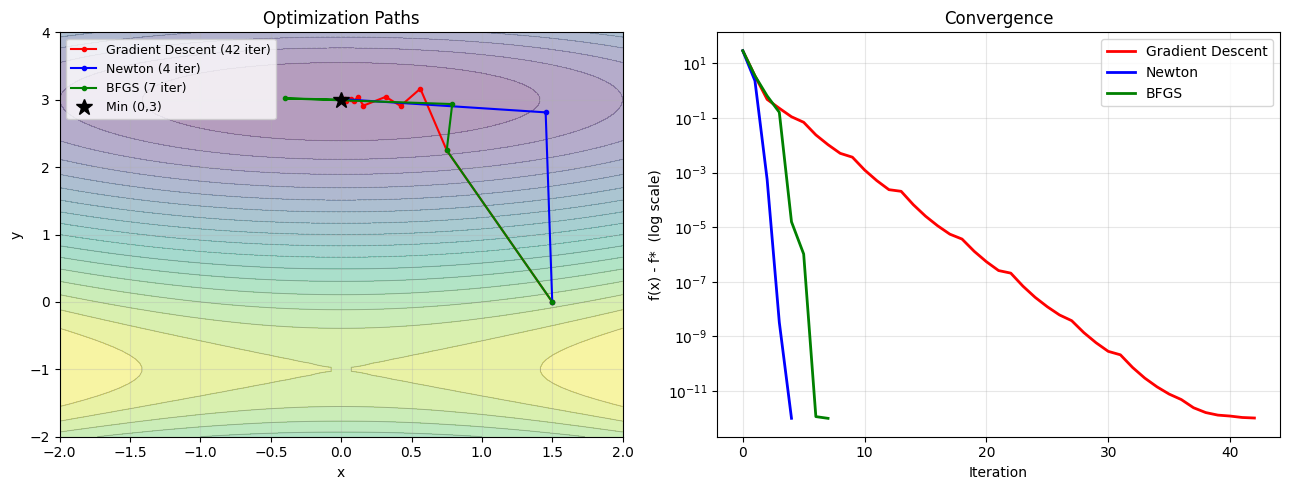

In [119]:
xr = np.linspace(-2, 2, 100)
yr = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(xr, yr)
Z = X**2 + Y**3 - 3*Y**2 - 9*Y + 5

methods = [('Gradient Descent', path_gd,     'red'),
           ('Newton',           path_newton,  'blue'),
           ('BFGS',             path_bfgs,    'green')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Optimization paths on contour
ax1.contourf(X, Y, Z, levels=20, alpha=0.4, cmap='viridis')
ax1.contour(X, Y, Z, levels=20, colors='gray', alpha=0.5, linewidths=0.7)
for name, path, color in methods:
    ax1.plot(path[:, 0], path[:, 1], '-o', color=color,
             markersize=3, linewidth=1.5, label=f'{name} ({len(path)-1} iter)')
ax1.plot(0, 3, 'k*', markersize=12, label='Min (0,3)')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Optimization Paths')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Convergence (log scale)
for name, path, color in methods:
    fvals = np.array([f(p) for p in path]) - F_STAR + 1e-12
    ax2.semilogy(fvals, color=color, linewidth=2, label=name)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('f(x) - f*  (log scale)')
ax2.set_title('Convergence')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()